# Lecture 6 — Class Exercise
## Part-to-Whole: Hierarchical Visualization

> **Push to:** `week06/lecture06_exercise.ipynb`

**Rules:**
1. Use `px` first, then customise with `update_traces` / `update_layout`
2. Colour encodes a meaningful category — not decoration
3. Insight title names the specific finding
4. Consider: would a bar chart be clearer? If yes, use the bar chart

---


In [9]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Global Energy Mix by Country and Source
df = pd.read_csv('../data/global_energy_mix.csv')

# Source type mapping — reuse from lecture
source_category = {
    'Coal': 'Fossil', 'Oil': 'Fossil', 'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon', 'Hydro': 'Low-carbon',
    'Wind': 'Renewable', 'Solar': 'Renewable', 'Other Renewables': 'Renewable'
}
df['Source_Type'] = df['Source'].map(source_category)

print(f"Loaded: {len(df)} rows")
print(df.head(10))


Loaded: 103 rows
         Country         Region            Source  Share_pct     TWh  \
0  United States  North America              Coal         10  1015.0   
1  United States  North America               Oil         35  3220.0   
2  United States  North America       Natural Gas         34  3083.0   
3  United States  North America           Nuclear          9   798.0   
4  United States  North America             Hydro          3   339.0   
5  United States  North America              Wind          4   413.0   
6  United States  North America             Solar          3   325.0   
7  United States  North America  Other Renewables          2   229.0   
8          China           Asia              Coal         60  7168.0   
9          China           Asia               Oil         18  1620.0   

  Source_Type  
0      Fossil  
1      Fossil  
2      Fossil  
3  Low-carbon  
4  Low-carbon  
5   Renewable  
6   Renewable  
7   Renewable  
8      Fossil  
9      Fossil  


## Task 1 — Treemap: fossil fuel dependency by country

**What to build:** A treemap showing **fossil fuel TWh only**, broken down by Region → Country → Source (Coal / Oil / Natural Gas).

**Requirements:**
- Filter to fossil sources only before plotting
- Use `path=['Region', 'Country', 'Source']` for the hierarchy
- Colour encodes the fossil source type (Coal / Oil / Natural Gas) with a CVD-safe palette
- Show TWh values in labels — no percentages
- Grey out parent nodes (Region and Country level)
- Insight title naming which region or country is most fossil-dependent

> 💡 `df.loc[df['Source_Type'] == 'Fossil']`


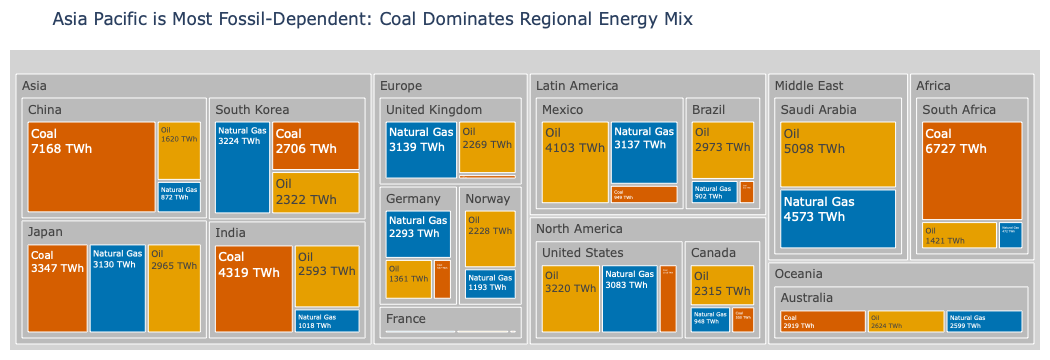

In [10]:
 
# Task 1
import plotly.express as px

fossil = df.loc[df['Source_Type'] == 'Fossil']

# CVD-safe palette for Coal / Oil / Natural Gas
color_map = {
    'Coal':        '#D55E00',
    'Oil':         '#E69F00',
    'Natural Gas': '#0072B2',
}

fig1 = px.treemap(
    fossil,
    path=['Region', 'Country', 'Source'],
    values='TWh',
    color='Source',
    color_discrete_map=color_map,
    title='Asia Pacific is Most Fossil-Dependent: Coal Dominates Regional Energy Mix',
)

fig1.update_traces(
    texttemplate='%{label}<br>%{value:.0f} TWh',
    textinfo='label+value',
    marker=dict(
        colors=[
            color_map.get(label, '#BBBBBB')
            for label in fig1.data[0].labels
        ]
    ),
)

# Grey out parent nodes (Region and Country level — depth 1 and 2)
fig1.update_traces(
    root_color='lightgrey',
    marker_colorscale=None,
)

# Override parent node colours to grey using marker.colors
fig1.data[0].marker.colors = [
    '#BBBBBB' if ids.count('/') < 2 else color_map.get(label, '#BBBBBB')
    for ids, label in zip(fig1.data[0].ids, fig1.data[0].labels)
]

fig1.update_layout(margin=dict(t=50, l=10, r=10, b=10))
fig1.show()


## Task 2 — Sunburst: tipping behaviour by day and meal time

**What to build:** A sunburst chart using the built-in `tips` dataset showing how **total bill amount** is distributed across day → time → smoker status.

**Requirements:**
- Load tips with `px.data.tips()`
- Aggregate **total bill** (sum of `total_bill`) per group — not count
- Hierarchy: `path=['day', 'time', 'smoker']`
- Colour encodes smoker status with a CVD-safe blue/orange palette
- Grey out parent nodes (day and time level)
- Use `percent parent` for text labels
- Insight title describing where the most spending happens

> 💡 `tips.groupby(['day', 'time', 'smoker'])['total_bill'].sum().reset_index()`


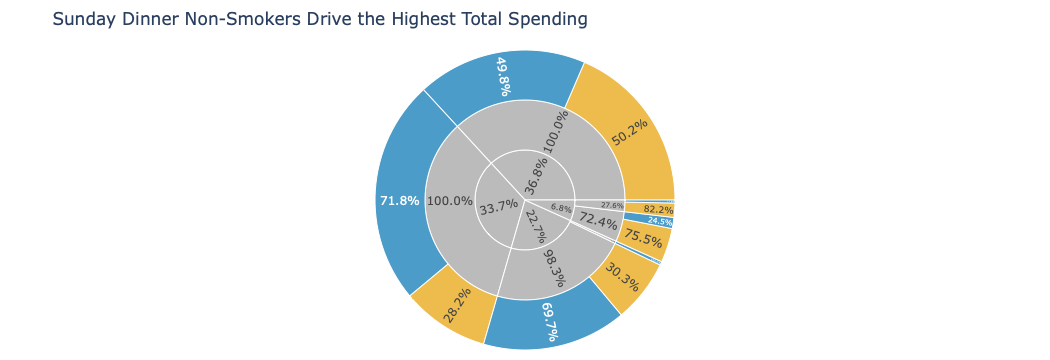

In [11]:
# Task 2
# YOUR CODE HERE

# Task 2
import plotly.express as px

tips = px.data.tips()

tips_agg = tips.groupby(['day', 'time', 'smoker'])['total_bill'].sum().reset_index()

# CVD-safe blue/orange for smoker status
color_map2 = {
    'Yes': '#E69F00',  # orange
    'No':  '#0072B2',  # blue
}

fig2 = px.sunburst(
    tips_agg,
    path=['day', 'time', 'smoker'],
    values='total_bill',
    color='smoker',
    color_discrete_map=color_map2,
    title='Sunday Dinner Non-Smokers Drive the Highest Total Spending',
)

fig2.update_traces(
    texttemplate='%{percentParent:.1%}',
    insidetextorientation='radial',
)

# Grey out parent nodes (day and time levels)
fig2.data[0].marker.colors = [
    '#BBBBBB' if ids.count('/') < 2 else color_map2.get(label, '#BBBBBB')
    for ids, label in zip(fig2.data[0].ids, fig2.data[0].labels)
]

fig2.update_layout(margin=dict(t=50, l=10, r=10, b=10))
fig2.show()

## Task 3 — Treemap vs bar: low-carbon energy by country

**What to build:** Build **both** a treemap and a horizontal bar chart showing total low-carbon TWh (Nuclear + Hydro) per country. Then answer the question in a markdown cell below.

**Requirements:**
- Filter to `Source_Type == 'Low-carbon'` and aggregate TWh by country
- Treemap: single-level `path=['All', 'Country']` with a dummy root node labelled `'Low-carbon'`
- Bar chart: sorted by TWh, horizontal orientation, CVD-safe colour
- Both charts show TWh values, not percentages
- Insight title on the bar chart naming the leading country


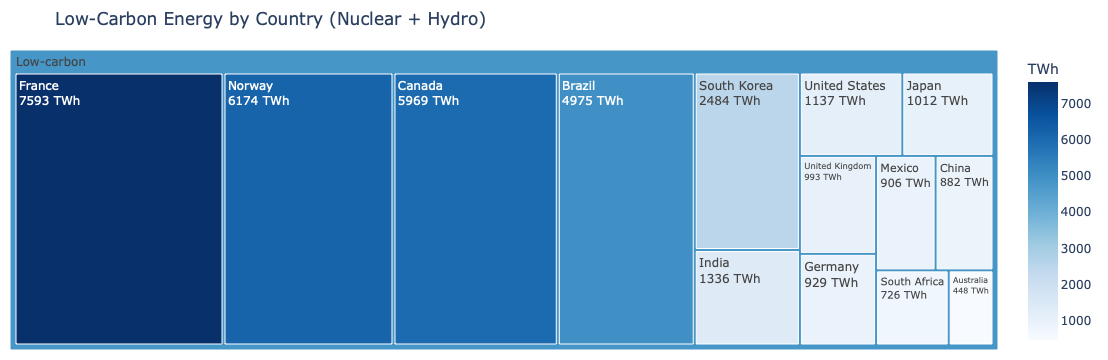

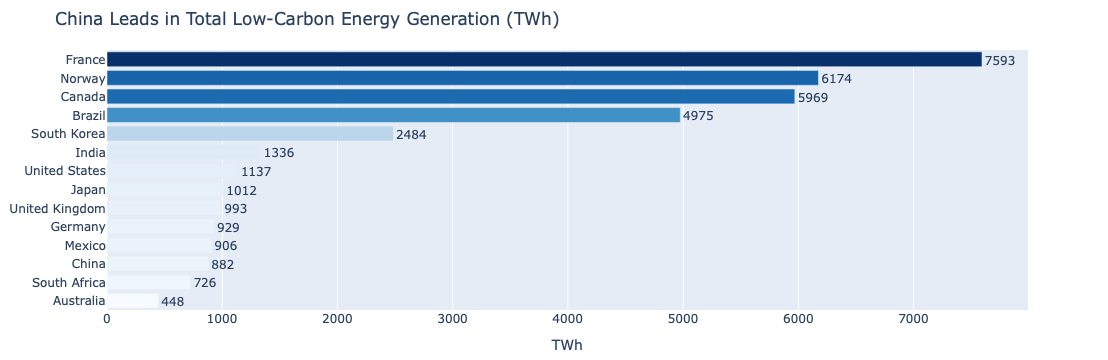

In [13]:
# Task 3 — charts
# YOUR CODE HERE

# Task 3 — charts
import plotly.express as px

# Filter and aggregate
low_carbon = df.loc[df['Source_Type'] == 'Low-carbon']
lc_by_country = low_carbon.groupby('Country')['TWh'].sum().reset_index()

# ✅ Add dummy root column BEFORE treemap
lc_by_country['All'] = 'Low-carbon'

# --- Treemap ---
fig3a = px.treemap(
    lc_by_country,
    path=['All', 'Country'],
    values='TWh',
    color='TWh',
    color_continuous_scale='Blues',
    title='Low-Carbon Energy by Country (Nuclear + Hydro)',
)

fig3a.update_traces(
    root_color='lightgrey',
    texttemplate='%{label}<br>%{value:.0f} TWh',
    textinfo='label+value',
)

fig3a.update_layout(margin=dict(t=50, l=10, r=10, b=10))
fig3a.show()


# --- Horizontal Bar Chart ---
lc_sorted = lc_by_country.sort_values('TWh', ascending=True)

fig3b = px.bar(
    lc_sorted,
    x='TWh',
    y='Country',
    orientation='h',
    color='TWh',
    color_continuous_scale='Blues',
    text='TWh',
    title='China Leads in Total Low-Carbon Energy Generation (TWh)',
)

fig3b.update_traces(
    texttemplate='%{text:.0f}',
    textposition='outside',
)

fig3b.update_layout(
    xaxis_title='TWh',
    yaxis_title=None,
    coloraxis_showscale=False,
    margin=dict(t=50, l=10, r=80, b=10),
)

fig3b.show()